# Milestone 2

- Feature Engineering
- Feature Selection
- Data Modelling

## Imports

In [8]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [9]:
full_df = pd.read_csv('../data/full_df.csv')

## Preprocessing full_df

### Dropping reviews columns

In [10]:


full_df.drop(columns=['review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'review_type'], inplace=True)


print(full_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106556 entries, 0 to 106555
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       106556 non-null  object 
 1   customer_id                    106556 non-null  object 
 2   order_status                   106556 non-null  object 
 3   order_purchase_timestamp       106556 non-null  object 
 4   order_approved_at              106556 non-null  object 
 5   order_delivered_carrier_date   105791 non-null  object 
 6   order_delivered_customer_date  104683 non-null  object 
 7   order_estimated_delivery_date  106556 non-null  object 
 8   delivery_time                  104683 non-null  float64
 9   delivery_difference            104683 non-null  float64
 10  payment_sequential             106556 non-null  int64  
 11  payment_type                   106556 non-null  object 
 12  payment_installments          

### Filling NULL Values with Mean Imputation or High Frequency Values

In [11]:
# Calculate the mean of the delivery_time column
mean_delivery_time = full_df['delivery_time'].mean()

# Fill null values in delivery_time with the mean
full_df['delivery_time'].fillna(mean_delivery_time, inplace=True)

# Convert order_purchase_timestamp to datetime
full_df['order_purchase_timestamp'] = pd.to_datetime(full_df['order_purchase_timestamp'])

# Fill null values in order_delivered_customer_date
full_df['order_delivered_customer_date'] = pd.to_datetime(full_df['order_delivered_customer_date'])
full_df['order_delivered_customer_date'].fillna(
    full_df['order_purchase_timestamp'] + pd.to_timedelta(mean_delivery_time, unit='D'),
    inplace=True
)

# Calculate the mean difference between order_delivered_carrier_date and order_approved_at
mean_carrier_delivery_diff = (
    pd.to_datetime(full_df['order_delivered_carrier_date']) - pd.to_datetime(full_df['order_approved_at'])
).dt.total_seconds().mean()

# Fill null values in order_delivered_carrier_date
full_df['order_delivered_carrier_date'] = pd.to_datetime(full_df['order_delivered_carrier_date'])
full_df['order_delivered_carrier_date'].fillna(
    pd.to_datetime(full_df['order_approved_at']) + pd.to_timedelta(mean_carrier_delivery_diff, unit='s'),
    inplace=True
)

# Fill null values in delivery_difference with the difference between order_delivered_customer_date and order_estimated_delivery_date
full_df['delivery_difference'].fillna(
    (full_df['order_delivered_customer_date'] - pd.to_datetime(full_df['order_estimated_delivery_date'])).dt.total_seconds() / (24 * 3600),
    inplace=True
)

# Display the updated info
print(full_df[['delivery_time', 'order_delivered_customer_date', 'order_delivered_carrier_date']].info())

C:\Users\srava\AppData\Local\Temp\ipykernel_3036\2338803013.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_df['delivery_time'].fillna(mean_delivery_time, inplace=True)
C:\Users\srava\AppData\Local\Temp\ipykernel_3036\2338803013.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106556 entries, 0 to 106555
Data columns (total 3 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   delivery_time                  106556 non-null  float64       
 1   order_delivered_customer_date  106556 non-null  datetime64[ns]
 2   order_delivered_carrier_date   106556 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1)
memory usage: 2.4 MB
None


C:\Users\srava\AppData\Local\Temp\ipykernel_3036\2338803013.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_df['order_delivered_carrier_date'].fillna(
C:\Users\srava\AppData\Local\Temp\ipykernel_3036\2338803013.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

### Correlation Matrix before Feature Engineering

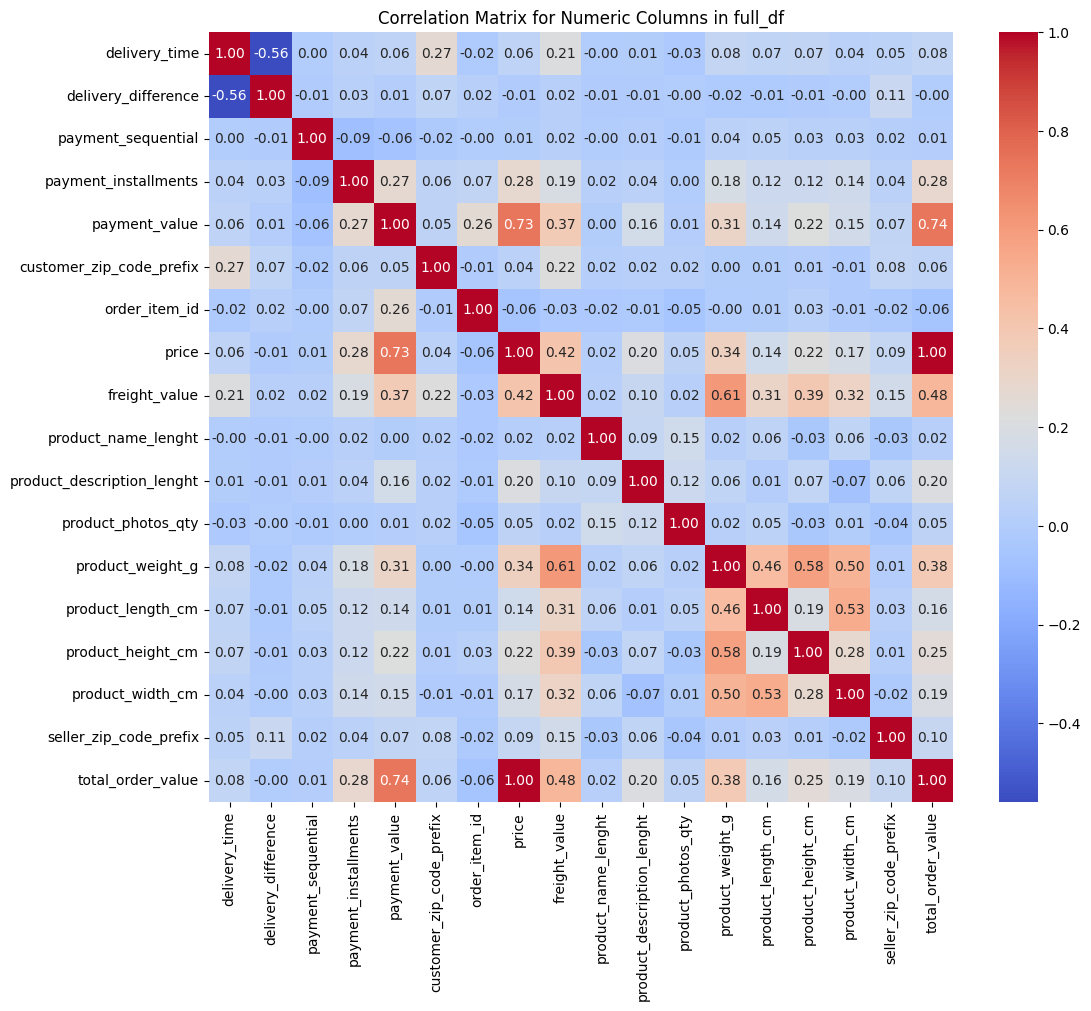

In [12]:
# Select only numeric columns from full_df
numeric_columns = full_df.select_dtypes(include=['number'])

# Compute the correlation matrix and display values in the heatmap
correlation_matrix = numeric_columns.corr()

# Visualize the correlation matrix using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix for Numeric Columns in full_df')
plt.show()

### Filtering Highly Correlating Features from Correlation Matrix

In [13]:
# Flatten the correlation matrix and reset the index
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

# Remove self-correlations and duplicate pairs
correlation_pairs = correlation_pairs[correlation_pairs['Feature1'] != correlation_pairs['Feature2']]
correlation_pairs = correlation_pairs.drop_duplicates(subset=['Correlation'])

# Sort by absolute correlation values in descending order
top_correlations = correlation_pairs.reindex(correlation_pairs['Correlation'].abs().sort_values(ascending=False).index)

# Display the top correlating pairs
print(top_correlations.head(10))

              Feature1             Feature2  Correlation
143              price    total_order_value     0.997104
89       payment_value    total_order_value     0.737647
79       payment_value                price     0.734052
156      freight_value     product_weight_g     0.612561
230   product_weight_g    product_height_cm     0.583365
1        delivery_time  delivery_difference    -0.559739
249  product_length_cm     product_width_cm     0.532556
231   product_weight_g     product_width_cm     0.504803
161      freight_value    total_order_value     0.483096
229   product_weight_g    product_length_cm     0.459246


## Feature Engineering

In [14]:
import sklearn

In [25]:
from sklearn.preprocessing import LabelEncoder

# 1. Interaction terms: Create interaction features between numeric columns
full_df['price_freight_interaction'] = full_df['price'] * full_df['freight_value']
full_df['price_installments_interaction'] = full_df['price'] * full_df['payment_installments']

# 2. Aggregations: Group by customer and calculate total and average order value
customer_aggregations = full_df.groupby('customer_unique_id').agg(
    total_order_value=('total_order_value', 'sum'),
    avg_order_value=('total_order_value', 'mean')
).reset_index()

# Rename columns to avoid duplicate names during merge
customer_aggregations.rename(columns={
    'total_order_value': 'customer_total_order_value',
    'avg_order_value': 'customer_avg_order_value'
}, inplace=True)

# Merge with the original dataframe
full_df = full_df.merge(customer_aggregations, on='customer_unique_id', how='left')

# 3. Time-based features: Extract year, month, and day from order_purchase_timestamp
full_df['order_purchase_year'] = pd.to_datetime(full_df['order_purchase_timestamp']).dt.year
full_df['order_purchase_month'] = pd.to_datetime(full_df['order_purchase_timestamp']).dt.month
full_df['order_purchase_day'] = pd.to_datetime(full_df['order_purchase_timestamp']).dt.day

# 4. Encode categorical variables using Label Encoding
label_encoder = LabelEncoder()
full_df['customer_state_encoded'] = label_encoder.fit_transform(full_df['customer_state'])
# full_df['seller_state_encoded'] = label_encoder.fit_transform(full_df['seller_state'])

# Display the first few rows of the updated dataframe
print(full_df[['price_freight_interaction', 'price_installments_interaction', 'total_order_value', 'order_purchase_year', 'order_purchase_month', 'order_purchase_day', 'customer_state_encoded']].head())

   price_freight_interaction  price_installments_interaction  \
0                   261.5128                           29.99   
1                   261.5128                           29.99   
2                   261.5128                           29.99   
3                  2701.6120                          118.70   
4                  3073.2780                          479.70   

   total_order_value  order_purchase_year  order_purchase_month  \
0              38.71                 2017                    10   
1              38.71                 2017                    10   
2              38.71                 2017                    10   
3             141.46                 2018                     7   
4             179.12                 2018                     8   

   order_purchase_day  customer_state_encoded  
0                   2                      25  
1                   2                      25  
2                   2                      25  
3                  2

In [15]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106556 entries, 0 to 106555
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       106556 non-null  object        
 1   customer_id                    106556 non-null  object        
 2   order_status                   106556 non-null  object        
 3   order_purchase_timestamp       106556 non-null  datetime64[ns]
 4   order_approved_at              106556 non-null  object        
 5   order_delivered_carrier_date   106556 non-null  datetime64[ns]
 6   order_delivered_customer_date  106556 non-null  datetime64[ns]
 7   order_estimated_delivery_date  106556 non-null  object        
 8   delivery_time                  106556 non-null  float64       
 9   delivery_difference            106556 non-null  float64       
 10  payment_sequential             106556 non-null  int64         
 11  

In [16]:
# # Feature Engineering
# # Create new features based on existing columns

# 1. Delivery performance: Difference between estimated and actual delivery time
full_df['delivery_performance'] = full_df['delivery_difference'] / full_df['delivery_time']

# # 2. Price per item: Price divided by the number of items in the order
# full_df['price_per_item'] = full_df['price'] / full_df['order_item_id']

# # 3. Freight ratio: Freight value as a percentage of the total order value
# full_df['freight_ratio'] = full_df['freight_value'] / full_df['total_order_value']

# 4. Payment per installment: Payment value divided by the number of installments
full_df['payment_per_installment'] = full_df['payment_value'] / full_df['payment_installments']

# 5. Product density: Weight divided by the product of length, width, and height
full_df['product_density'] = full_df['product_weight_g'] / (
    full_df['product_length_cm'] * full_df['product_width_cm'] * full_df['product_height_cm']
)

# # 6. Review sentiment: Categorize review scores into positive, neutral, and negative
# full_df['review_sentiment'] = full_df['review_score'].apply(
#     lambda x: 'positive' if x >= 4 else 'neutral' if x == 3 else 'negative'
# )

# Display the first few rows of the updated dataframe
print(full_df[['delivery_performance', 'payment_per_installment', 'product_density']].head())

   delivery_performance  payment_per_installment  product_density
0              0.875000                18.120000         0.253036
1              0.875000                 2.000000         0.253036
2              0.875000                18.590000         0.253036
3              0.384615               141.460000         0.085233
4              1.888889                59.706667         0.043860


In [17]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106556 entries, 0 to 106555
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       106556 non-null  object        
 1   customer_id                    106556 non-null  object        
 2   order_status                   106556 non-null  object        
 3   order_purchase_timestamp       106556 non-null  datetime64[ns]
 4   order_approved_at              106556 non-null  object        
 5   order_delivered_carrier_date   106556 non-null  datetime64[ns]
 6   order_delivered_customer_date  106556 non-null  datetime64[ns]
 7   order_estimated_delivery_date  106556 non-null  object        
 8   delivery_time                  106556 non-null  float64       
 9   delivery_difference            106556 non-null  float64       
 10  payment_sequential             106556 non-null  int64         
 11  

### Correlation Matrix after Feature Engineering

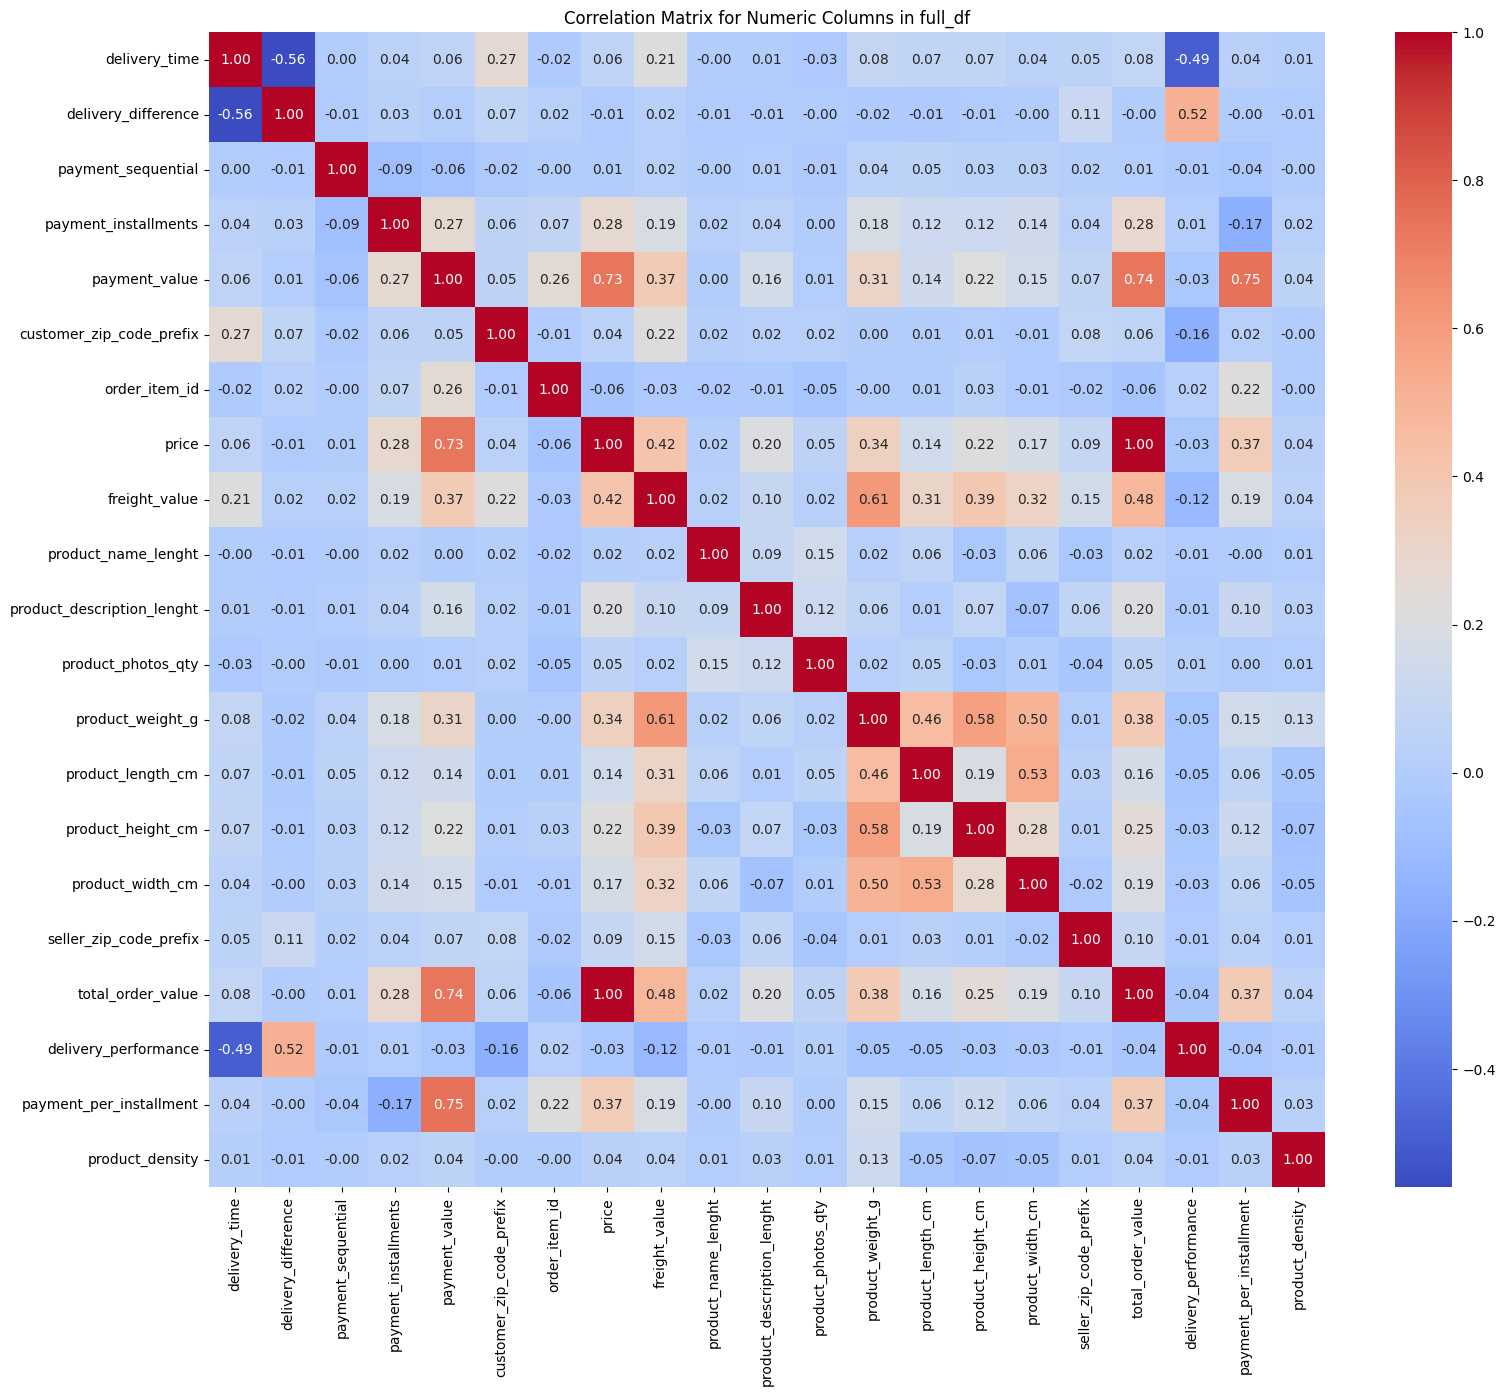

In [18]:
# Select only numeric columns from full_df
numeric_columns = full_df.select_dtypes(include=['number'])

# Compute the correlation matrix and display values in the heatmap
correlation_matrix = numeric_columns.corr()

# Visualize the correlation matrix using seaborn
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix for Numeric Columns in full_df')
plt.show()

### Removing irrelevant and unimportant features

In [19]:
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Feature Importance using LASSO
X = numeric_columns.drop(columns=['delivery_time'])  # Exclude target variable
y = numeric_columns['delivery_time']  # Target variable

# Handle missing or infinite values in X
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LASSO for feature selection
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

# Get feature importance
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lasso.coef_
}).sort_values(by='Importance', ascending=False)

print("LASSO Feature Importance:")
print(lasso_importance)

# 2. Dimensionality Reduction using PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA reduced dimensions: {X_pca.shape[1]}")

LASSO Feature Importance:
                       Feature  Importance
4     customer_zip_code_prefix    2.131312
7                freight_value    1.498756
15      seller_zip_code_prefix    0.491821
2         payment_installments    0.240898
12           product_length_cm    0.185544
13           product_height_cm    0.164742
18     payment_per_installment    0.077536
19             product_density    0.072409
16           total_order_value   -0.000000
5                order_item_id   -0.000000
3                payment_value   -0.000000
1           payment_sequential   -0.001648
8          product_name_lenght   -0.047344
14            product_width_cm   -0.092963
9   product_description_lenght   -0.165278
10          product_photos_qty   -0.233101
6                        price   -0.234159
11            product_weight_g   -0.396314
17        delivery_performance   -1.698296
0          delivery_difference   -4.555523

PCA reduced dimensions: 16


In [20]:
# Define a threshold for importance (e.g., features with absolute importance > 0.1 are considered important)
importance_threshold = 0.1

# Separate important and unimportant features
important_features = lasso_importance[lasso_importance['Importance'].abs() > importance_threshold]
unimportant_features = lasso_importance[lasso_importance['Importance'].abs() <= importance_threshold]

# Display the results
print("Important Features:")
print(important_features)

print("\nUnimportant Features:")
print(unimportant_features)

Important Features:
                       Feature  Importance
4     customer_zip_code_prefix    2.131312
7                freight_value    1.498756
15      seller_zip_code_prefix    0.491821
2         payment_installments    0.240898
12           product_length_cm    0.185544
13           product_height_cm    0.164742
9   product_description_lenght   -0.165278
10          product_photos_qty   -0.233101
6                        price   -0.234159
11            product_weight_g   -0.396314
17        delivery_performance   -1.698296
0          delivery_difference   -4.555523

Unimportant Features:
                    Feature  Importance
18  payment_per_installment    0.077536
19          product_density    0.072409
16        total_order_value   -0.000000
5             order_item_id   -0.000000
3             payment_value   -0.000000
1        payment_sequential   -0.001648
8       product_name_lenght   -0.047344
14         product_width_cm   -0.092963


In [21]:
# Remove the specified attributes
full_df.drop(columns=['payment_per_installment', 'product_name_lenght', 'product_description_lenght', 'product_density'], inplace=True)

## Predicting Delivery Times (Data Modelling)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

### Selecting Required Features

In [23]:
# Drop rows with missing values in 'delivery_time'
full_df = full_df.dropna(subset=['delivery_time'])

# Select features and target variable
features = ['product_category_name', 'customer_city', 'order_purchase_month', 'freight_value','delivery_difference']
target = 'delivery_time'

### Label Encoding

In [26]:
# Encode categorical variables
full_df['product_category_name_encoded'] = label_encoder.fit_transform(full_df['product_category_name'])
full_df['customer_city_encoded'] = label_encoder.fit_transform(full_df['customer_city'])
full_df['order_purchase_month_encoded'] = label_encoder.fit_transform(full_df['order_purchase_month'])

print(full_df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [29]:
# Update features with encoded columns
features = ['product_category_name_encoded', 'customer_city_encoded', 'order_purchase_month_encoded', 'freight_value', 'delivery_difference']

### Test and Train Split

In [30]:
# Split data into training and testing sets
X = full_df[features]
y = full_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training with Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression

# Initalize the Linear Regression model
linear_model = LinearRegression()

# Train the Linear Regression model
linear_model.fit(X_train, y_train)

# Predict on test set
linear_pred = linear_model.predict(X_test)

# Evaluate model
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

# Print results
print("Linear Regression:")
print(f"MAE: {linear_mae}, MSE: {linear_mse}, R²: {linear_r2}")


Linear Regression:
MAE: 5.424503950168777, MSE: 54.03143337161757, R²: 0.3774388448055278


### RUC and AOC for Linear Regression

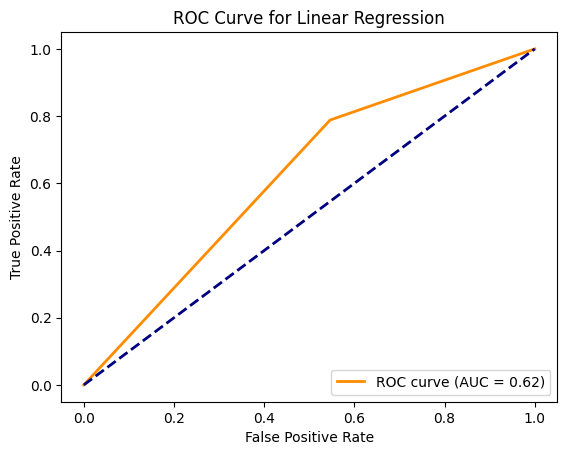

In [32]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Define a threshold to convert regression predictions into binary classification
threshold = 10  # Example threshold

# Convert predictions and actual values into binary classes
y_test_binary = (y_test > threshold).astype(int)
linear_pred_binary = (linear_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, linear_pred_binary)
auc_lr = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Linear Regression')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 scores for Linear Regression

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
precision = precision_score(y_test_binary, linear_pred_binary)
recall = recall_score(y_test_binary, linear_pred_binary)
f1 = f1_score(y_test_binary, linear_pred_binary)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.563463314155835
Recall: 0.7884118465513814
F1-Score: 0.657222153183381


### Training with Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict on test set
rf_pred = rf_model.predict(X_test)

# Evaluate model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Print results
print("Random Forest:")
print(f"MAE: {rf_mae}, MSE: {rf_mse}, R²: {rf_r2}")

Random Forest:
MAE: 2.8903445776889884, MSE: 19.668807900748668, R²: 0.773371998411197


### RUC and AOC for Random Forest Regressor

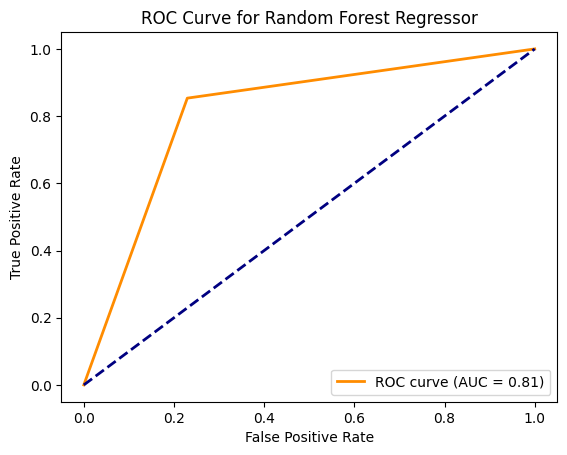

In [35]:
# Define a threshold to convert regression predictions into binary classification
threshold = 10  # Example threshold

# Convert predictions and actual values into binary classes
y_test_binary = (y_test > threshold).astype(int)
rf_pred_binary = (rf_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, rf_pred_binary)
auc_rfr = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_rfr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Regressor')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 Scores for Random Forest Regressor

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert predictions and actual values into binary classes
rf_pred_binary = (rf_pred > threshold).astype(int)

# Calculate precision, recall, and F1-score
rf_precision = precision_score(y_test_binary, rf_pred_binary)
rf_recall = recall_score(y_test_binary, rf_pred_binary)
rf_f1 = f1_score(y_test_binary, rf_pred_binary)

# Print the results
print("Random Forest Regressor:")
print(f"Precision: {rf_precision}")
print(f"Recall: {rf_recall}")
print(f"F1-Score: {rf_f1}")

Random Forest Regressor:
Precision: 0.7688451208594449
Recall: 0.8535082488570861
F1-Score: 0.8089675960813866


### Training with Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize model
gbr_model = GradientBoostingRegressor(random_state=42)

# Train models
gbr_model.fit(X_train, y_train)

# Predict on test set
gbr_pred = gbr_model.predict(X_test)

# Evaluate model
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_r2 = r2_score(y_test, gbr_pred)

# Print results
print("\nGradient Boosting Regressor:")
print(f"MAE: {gbr_mae}, MSE: {gbr_mse}, R²: {gbr_r2}")


Gradient Boosting Regressor:
MAE: 4.0206148253690035, MSE: 31.827831311069897, R²: 0.6332732598065209


### ROC and AUC for Gradient Boosting Regressor

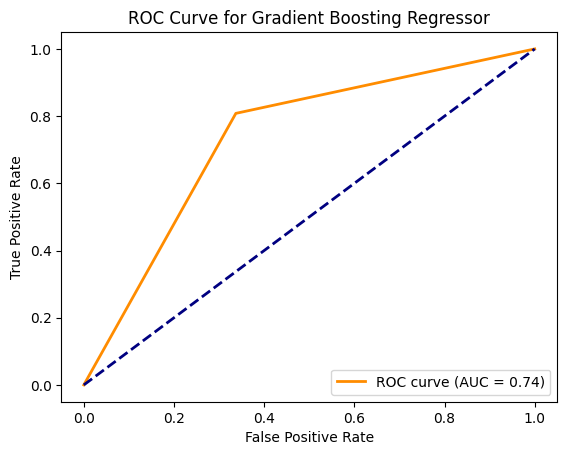

In [ ]:
# Define a threshold to convert regression predictions into binary classification

# Convert predictions and actual values into binary classes
y_test_binary = (y_test > threshold).astype(int)
gbr_pred_binary = (gbr_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, gbr_pred_binary)
auc_gbr = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_gbr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Gradient Boosting Regressor')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 Scores for Gradient Boosting Regressor

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert predictions and actual values into binary classes
gbr_pred_binary = (gbr_pred > threshold).astype(int)

# Calculate precision, recall, and F1-score
gbr_precision = precision_score(y_test_binary, gbr_pred_binary)
gbr_recall = recall_score(y_test_binary, gbr_pred_binary)
gbr_f1 = f1_score(y_test_binary, gbr_pred_binary)

# Print the results
print("Gradient Boosting Regressor:")
print(f"Precision: {gbr_precision}")
print(f"Recall: {gbr_recall}")
print(f"F1-Score: {gbr_f1}")

Gradient Boosting Regressor:
Precision: 0.6819287211740042
Recall: 0.808189226793878
F1-Score: 0.7397098285350434


### Training with SVR

In [ ]:
from sklearn.svm import SVR

# Initialize model
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Train model
svr_model.fit(X_train, y_train)

# Predict on test set
# xgb_pred = xgb_model.predict(X_test)
svr_pred = svr_model.predict(X_test)


svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("\nSupport Vector Regressor:")
print(f"MAE: {svr_mae}, MSE: {svr_mse}, R²: {svr_r2}")


Support Vector Regressor:
MAE: 5.616266399709132, MSE: 81.48943021489376, R²: 0.06106222535689887


### ROC, AUC for SVR

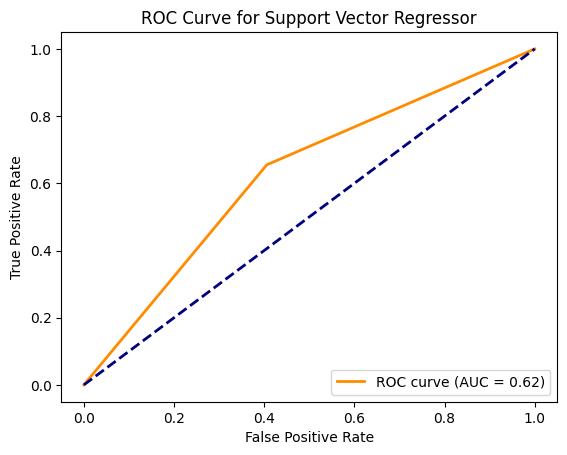

In [ ]:
# Define a threshold to convert regression predictions into binary classification
# Convert predictions and actual values into binary classes
svr_pred_binary = (svr_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, svr_pred_binary)
auc_svr = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_svr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Support Vector Regressor')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 Scores for SVR

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score for SVR
svr_precision = precision_score(y_test_binary, svr_pred_binary)
svr_recall = recall_score(y_test_binary, svr_pred_binary)
svr_f1 = f1_score(y_test_binary, svr_pred_binary)

# Print the results
print("Support Vector Regressor:")
print(f"Precision: {svr_precision}")
print(f"Recall: {svr_recall}")
print(f"F1-Score: {svr_f1}")

Support Vector Regressor:
Precision: 0.5908194369732831
Recall: 0.6549393758696084
F1-Score: 0.6212292609351433


In [ ]:

# Create a dictionary with model names and their respective metrics
model_metrics = {
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Support Vector Regressor'],
    # 'MSE': [linear_mse, rf_mse, gbr_mse, svr_mse],
    # 'MAE': [linear_mae, rf_mae, gbr_mae, svr_mae],
    'R²': [linear_r2, rf_r2, gbr_r2, svr_r2],
    'AUC': [auc_lr, auc_rfr, auc_gbr, auc_svr],  # Replace with individual AUC values if available
    'Precision': [precision, rf_precision, gbr_precision, svr_precision],
    'Recall': [recall, rf_recall, gbr_recall, svr_recall],
    'F1 Score': [f1, rf_f1, gbr_f1, svr_f1]
}

# Convert the dictionary to a pandas DataFrame
metrics_df = pd.DataFrame(model_metrics)

# Display the table
print(metrics_df)

                      Model        R²       AUC  Precision    Recall  F1 Score
0         Linear Regression  0.375199  0.621143   0.562959  0.792685  0.658357
1             Random Forest  0.743542  0.782781   0.730178  0.844762  0.783302
2         Gradient Boosting  0.633273  0.735517   0.681929  0.808189  0.739710
3  Support Vector Regressor  0.061062  0.624625   0.590819  0.654939  0.621229


# Prediction Model for Freight Value

### Selecting Required Features

In [39]:
# Identify features that correlate the most with 'freight_value'
freight_value_correlations = correlation_matrix['freight_value'].sort_values(ascending=False)
top_freight_features = freight_value_correlations[1:5].index.tolist()  # Select top 4 features excluding 'freight_value'

print("Top features correlated with 'freight_value':")
print(top_freight_features)


Top features correlated with 'freight_value':
['product_weight_g', 'total_order_value', 'price', 'product_height_cm']


### Label Encoding for freight_value

In [40]:
full_df['product_weight_g_encoded'] = label_encoder.fit_transform(full_df['product_weight_g'])
full_df['total_order_value_encoded'] = label_encoder.fit_transform(full_df['total_order_value'])
full_df['price_encoded'] = label_encoder.fit_transform(full_df['price'])

In [41]:
freight_target = 'freight_value'
freight_features = ['product_weight_g_encoded', 'total_order_value_encoded', 'price_encoded']

### Split into Training and Testing data

In [43]:
# Split data into training and testing sets
X_freight = full_df[freight_features]
y_freight = full_df[freight_target]
X_freight_train, X_freight_test, y_freight_train, y_freight_test = train_test_split(X_freight, y_freight, test_size=0.2, random_state=42)

### Training with Linear Regression

In [44]:
# Initialize the Linear Regression model
linear_freight_model = LinearRegression()

# Train the model
linear_freight_model.fit(X_freight_train, y_freight_train)

# Predict on the test set
linear_freight_pred = linear_freight_model.predict(X_freight_test)

# Evaluate the model
linear_freight_mae = mean_absolute_error(y_freight_test, linear_freight_pred)
linear_freight_mse = mean_squared_error(y_freight_test, linear_freight_pred)
linear_freight_r2 = r2_score(y_freight_test, linear_freight_pred)

# Print results
print("Linear Regression for Freight Value:")
print(f"MAE: {linear_freight_mae}")
print(f"MSE: {linear_freight_mse}")
print(f"R²: {linear_freight_r2}")

Linear Regression for Freight Value:
MAE: 5.644252047032263
MSE: 105.09801646723298
R²: 0.5642931217600545


### ROC and AUC for Linear Regression

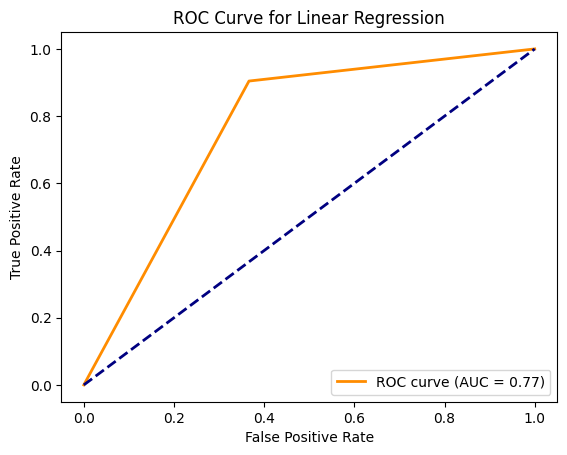

In [45]:
# Define a threshold to convert regression predictions into binary classification
threshold = 10  # Example threshold

# Convert predictions and actual values into binary classes
y_freight_test_binary = (y_freight_test > threshold).astype(int)
linear_freight_pred_binary = (linear_freight_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr_freight, tpr_freight, _ = roc_curve(y_freight_test_binary, linear_freight_pred_binary)
auc_lr_freight = auc(fpr_freight, tpr_freight)

# Plot ROC curve
plt.figure()
plt.plot(fpr_freight, tpr_freight, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_lr_freight:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Linear Regression')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 scores for Linear Regression

In [46]:
# Calculate precision, recall, and F1-score for Linear Regression (freight_value)
linear_freight_precision = precision_score(y_freight_test_binary, linear_freight_pred_binary)
linear_freight_recall = recall_score(y_freight_test_binary, linear_freight_pred_binary)
linear_freight_f1 = f1_score(y_freight_test_binary, linear_freight_pred_binary)

# Print the results
print("Linear Regression for Freight Value:")
print(f"Precision: {linear_freight_precision}")
print(f"Recall: {linear_freight_recall}")
print(f"F1-Score: {linear_freight_f1}")

Linear Regression for Freight Value:
Precision: 0.9431671257518691
Recall: 0.904376886589047
F1-Score: 0.923364794584629


### Training with Random Forest Regressor

In [47]:
# Initialize the Random Forest model
rf_freight_model = RandomForestRegressor(random_state=42)

# Train the Random Forest model
rf_freight_model.fit(X_freight_train, y_freight_train)

# Predict on the test set
rf_freight_pred = rf_freight_model.predict(X_freight_test)

# Evaluate the model
rf_freight_mae = mean_absolute_error(y_freight_test, rf_freight_pred)
rf_freight_mse = mean_squared_error(y_freight_test, rf_freight_pred)
rf_freight_r2= r2_score(y_freight_test, rf_freight_pred)

# Print results
print("Random Forest Regressor:")
print(f"MAE: {rf_freight_mae}, MSE: {rf_freight_mse}, R²: {rf_freight_r2}")

Random Forest Regressor:
MAE: 0.532859051238744, MSE: 11.940284110624532, R²: 0.9504989333765377


### ROC and AUC for Random Forest

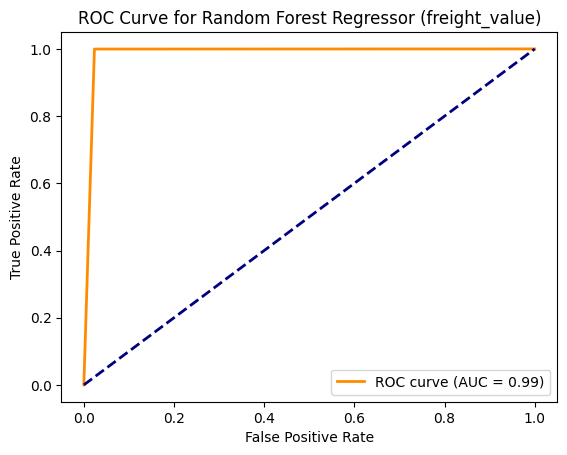

In [48]:
# Define a threshold to convert regression predictions into binary classification
threshold = 10  # Example threshold

# Convert predictions and actual values into binary classes
rf_freight_pred_binary = (rf_freight_pred > threshold).astype(int)

# Compute ROC curve and AUC
fpr_rf_freight, tpr_rf_freight, _ = roc_curve(y_freight_test_binary, rf_freight_pred_binary)
auc_rf_freight = auc(fpr_rf_freight, tpr_rf_freight)

# Plot ROC curve
plt.figure()
plt.plot(fpr_rf_freight, tpr_rf_freight, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_rf_freight:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Regressor (freight_value)')
plt.legend(loc='lower right')
plt.show()

### Precision, Recall, F1 scores for Random Forest

In [49]:
# Calculate precision, recall, and F1-score
rf_freight_precision = precision_score(y_freight_test_binary, rf_pred_binary)
rf_freight_recall = recall_score(y_freight_test_binary, rf_freight_pred_binary)
rf_freight_f1 = f1_score(y_freight_test_binary, rf_freight_pred_binary)

# Print the results
print("Random Forest Regressor:")
print(f"Precision: {rf_freight_precision}")
print(f"Recall: {rf_freight_recall}")
print(f"F1-Score: {rf_freight_f1}")

Random Forest Regressor:
Precision: 0.968845120859445
Recall: 0.9996226821905994
F1-Score: 0.9980625370001615


In [50]:

# Create a dictionary with model names and their respective metrics
freight_model_metrics = {
    'Model': ['Linear Regression', 'Random Forest'],
    'R²': [linear_freight_r2, rf_freight_r2],
    'AUC': [auc_lr_freight, auc_rf_freight], 
    'Precision': [linear_freight_precision, rf_freight_precision],
    'Recall': [linear_freight_recall, rf_freight_recall],
    'F1 Score': [linear_freight_f1, rf_freight_f1]
}

# Convert the dictionary to a pandas DataFrame
freight_metrics_df = pd.DataFrame(freight_model_metrics)

# Display the table
print(freight_metrics_df)

               Model        R²       AUC  Precision    Recall  F1 Score
0  Linear Regression  0.564293  0.769036   0.943167  0.904377  0.923365
1      Random Forest  0.950499  0.988036   0.968845  0.999623  0.998063


In [37]:
full_df.to_csv('../data/full_df2.csv', index=False)
print("The full_df2.csv file has been updated with the new features")

The full_df2.csv file has been updated with the new features


In [51]:
import joblib

joblib.dump(rf_model, '../Models/random_forest_model.pkl')
print("The Random Forest model has been saved as random_forest_model.pkl")

# Save the Random Forest model to a .pkl file
joblib.dump(rf_freight_model, '../Models/rf_freight_model.pkl')

print("Random Forest model for freight_value has been saved to 'rf_freight_model.pkl'")

The Random Forest model has been saved as random_forest_model.pkl
Random Forest model for freight_value has been saved to 'rf_freight_model.pkl'
